# Análisis exploratorio de los datos

### Librerias requeridas

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')


In [9]:
df = pd.read_csv("../data/raw/bs140513_032310.csv",delimiter=";")

In [10]:
print("Tamaño del dataset: ",df.shape)
df.info()

Tamaño del dataset:  (594643, 10)
<class 'pandas.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  str    
 2   age          594643 non-null  str    
 3   gender       594643 non-null  str    
 4   zipcodeOri   594643 non-null  str    
 5   merchant     594643 non-null  str    
 6   zipMerchant  594643 non-null  str    
 7   category     594643 non-null  str    
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 45.4 MB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,594643.0,94.986827,51.053632,0.0,52.00,97.0,139.00,179.00
amount,594643.0,37.890135,111.402831,0.0,13.74,26.9,42.54,8329.96
fraud,594643.0,0.012108,0.109369,0.0,0.00,0.0,0.00,1.00


In [12]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0]

Series([], dtype: int64)

In [13]:
df['fraud'].value_counts()

fraud
0    587443
1      7200
Name: count, dtype: int64

In [14]:
# En porcentaje
df['fraud'].value_counts(normalize=True) * 100

fraud
0    98.789189
1     1.210811
Name: proportion, dtype: float64

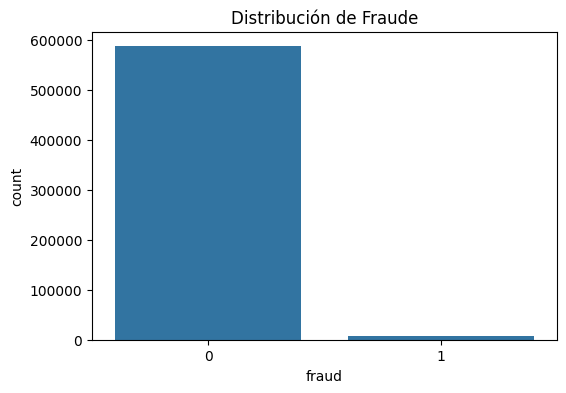

In [15]:
# Visualización
plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title('Distribución de Fraude')
plt.show()

## Categoria amount

Miramos a ver como se distribuye la categoria de amount buscando posibles outliers

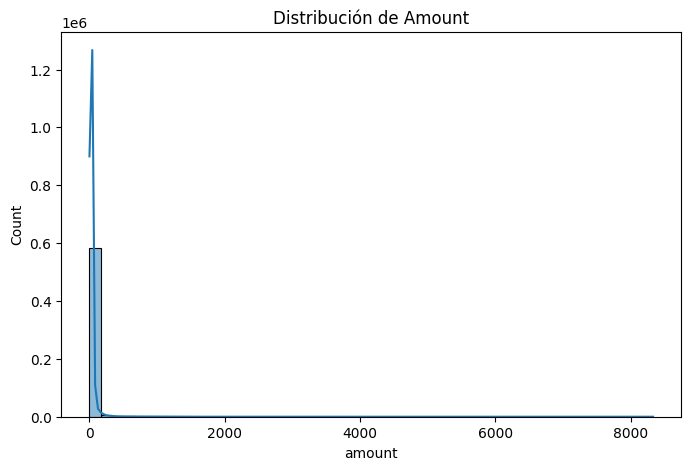

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribución de Amount')
plt.show()

Vemos claramente que existen outliers ya que la mayoria de los datos se encuentran siendo cercanos a 0, miramos ahora a ver los valores de amount como se relaccionan con el fraude

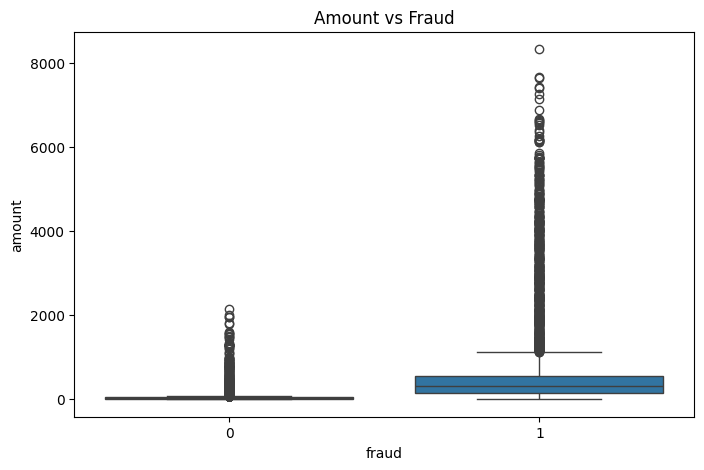

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud', y='amount', data=df)
plt.title('Amount vs Fraud')
plt.show()

Podemos apreciar que los valores mas altos son aquellos que son mas suceptibles para ser fraude lo que deberemos tener en cuenta en un futuro

## División variables categoricas

In [18]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant',
       'category'],
      dtype='str')

## Relacción de merchants y clients

In [19]:
# Número de clientes únicos
df['customer'].nunique()

# Número de comercios únicos
df['merchant'].nunique()

50

In [20]:
fraud_by_merchant = df.groupby('merchant')['fraud'].mean().sort_values(ascending=False)

fraud_by_merchant.head(10)

merchant
'M1294758098'    0.963351
'M3697346'       0.941558
'M1873032707'    0.864000
'M732195782'     0.851974
'M980657600'     0.832109
'M1353266412'    0.820513
'M857378720'     0.754098
'M2080407379'    0.750000
'M2011752106'    0.680328
'M17379832'      0.631206
Name: fraud, dtype: float64

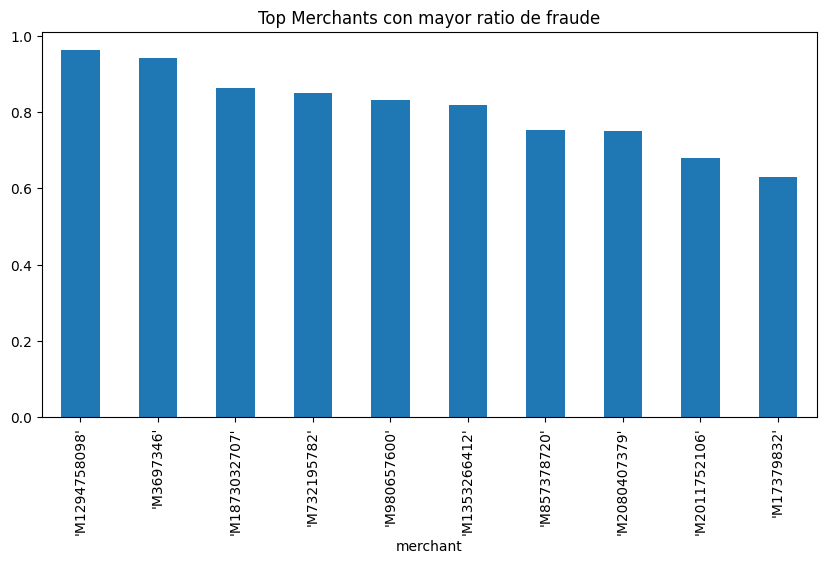

In [21]:
top_merchants = fraud_by_merchant.head(10)

plt.figure(figsize=(10,5))
top_merchants.plot(kind='bar')
plt.title('Top Merchants con mayor ratio de fraude')
plt.show()

Podemos ver que existen unos merchants con un mayor indice de fraude lo que nos indica que algo puede estar pasando con esos merchants, tendriamos que realizar un analisis de los datos de amount y que porcentaje representa el frsude por cada merchant.

### Análisis del fraude por merchant

In [24]:
merchant_analysis = df.groupby('merchant').agg({
    'fraud': ['count', 'sum', 'mean'],
    'amount': ['sum', 'mean']
})

# Aplanar columnas
merchant_analysis.columns = [
    'n_transactions',
    'n_fraud',
    'fraud_ratio',
    'total_amount',
    'avg_amount'
]

# Calcular amount fraudulento
fraud_amount = df[df['fraud'] == 1].groupby('merchant')['amount'].sum()

merchant_analysis['fraud_amount'] = fraud_amount

# Rellenar NaN (merchants sin fraude)
merchant_analysis['fraud_amount'] = merchant_analysis['fraud_amount'].fillna(0)

merchant_analysis.head()

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M1053599405',6821,0,0.000000,703056.31,103.072322,0.00
'M117188757',21,0,0.000000,2207.15,105.102381,0.00
'M1198415165',1580,358,0.226582,149504.20,94.622911,80191.83
'M1294758098',191,184,0.963351,55326.42,289.667120,54808.34
'M1313686961',527,0,0.000000,23500.82,44.593586,0.00


#### Merchants con mas fraude por ratio

In [25]:
merchant_analysis.sort_values('fraud_ratio', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M1294758098',191,184,0.963351,55326.42,289.667120,54808.34
'M3697346',308,290,0.941558,88840.32,288.442597,87527.64
'M1873032707',250,216,0.864000,94059.33,376.237320,90653.68
'M732195782',608,518,0.851974,1413661.65,2325.101398,1350979.31
'M980657600',1769,1472,0.832109,530635.69,299.963646,505311.62
'M1353266412',78,64,0.820513,29470.62,377.828462,28180.77
'M857378720',122,92,0.754098,43460.67,356.235000,39963.37
'M2080407379',48,36,0.750000,110376.59,2299.512292,103583.41
'M2011752106',244,166,0.680328,78953.83,323.581270,70246.52


#### Merchant con mas fraude por volumen 

In [26]:
merchant_analysis.sort_values('fraud_amount', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M732195782',608,518,0.851974,1413661.65,2325.101398,1350979.31
'M480139044',3508,1634,0.465792,858388.22,244.694475,664804.39
'M980657600',1769,1472,0.832109,530635.69,299.963646,505311.62
'M2080407379',48,36,0.750000,110376.59,2299.512292,103583.41
'M2122776122',341,200,0.586510,109999.72,322.579824,93889.68
'M1873032707',250,216,0.864000,94059.33,376.237320,90653.68
'M3697346',308,290,0.941558,88840.32,288.442597,87527.64
'M495352832',69,24,0.347826,111691.89,1618.723043,83381.34
'M1198415165',1580,358,0.226582,149504.20,94.622911,80191.83


#### Merchant mas activos

In [27]:
merchant_analysis.sort_values('n_transactions', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M1823072687',299693,0,0.000000,8077669.06,26.953146,0.00
'M348934600',205426,0,0.000000,5539423.40,26.965542,0.00
'M85975013',26254,0,0.000000,973246.41,37.070405,0.00
'M1053599405',6821,0,0.000000,703056.31,103.072322,0.00
'M151143676',6373,120,0.018829,276977.04,43.461014,19691.12
'M855959430',6098,280,0.045917,280327.63,45.970421,47391.52
'M1946091778',5343,0,0.000000,304913.51,57.067848,0.00
'M1913465890',3988,0,0.000000,416513.34,104.441660,0.00
'M209847108',3814,106,0.027792,237961.65,62.391623,24524.59


#### Merchants por volumen de fraude

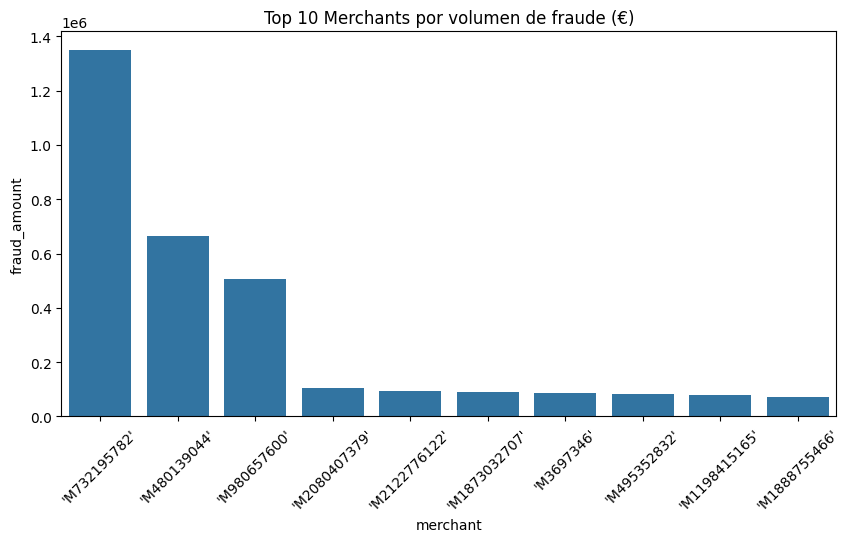

In [28]:
top_merchants = merchant_analysis.sort_values('fraud_amount', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_merchants.index, y=top_merchants['fraud_amount'])
plt.xticks(rotation=45)
plt.title('Top 10 Merchants por volumen de fraude (€)')
plt.show()

### Análisis de fraude por cliente

In [29]:
customer_analysis = df.groupby('customer').agg({
    'fraud': ['count', 'sum', 'mean'],
    'amount': ['sum', 'mean']
})

customer_analysis.columns = [
    'n_transactions',
    'n_fraud',
    'fraud_ratio',
    'total_amount',
    'avg_amount'
]

# Amount fraudulento
fraud_amount_cust = df[df['fraud'] == 1].groupby('customer')['amount'].sum()

customer_analysis['fraud_amount'] = fraud_amount_cust
customer_analysis['fraud_amount'] = customer_analysis['fraud_amount'].fillna(0)

customer_analysis.head()

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C1000148617',131,1,0.007634,4597.04,35.091908,323.64
'C100045114',109,5,0.045872,9846.65,90.336239,5004.46
'C1000699316',94,0,0.000000,3586.56,38.154894,0.00
'C1001065306',30,11,0.366667,6142.64,204.754667,4465.43
'C1002658784',131,0,0.000000,4487.18,34.253282,0.00


#### Clientes mas fraudulentos por ratio

In [30]:
customer_analysis.sort_values('fraud_ratio', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C910454738',92,87,0.945652,37795.51,410.820761,37143.84
'C2004941826',126,119,0.944444,64751.08,513.897460,64165.54
'C381007057',100,89,0.890000,51388.87,513.888700,50245.22
'C1572610482',101,89,0.881188,58687.13,581.060693,58203.13
'C617723960',46,40,0.869565,23823.87,517.910217,23443.52
'C2113737065',91,79,0.868132,39340.93,432.317912,38150.95
'C2060410910',13,11,0.846154,7305.33,561.948462,7213.91
'C483912131',98,80,0.816327,50462.72,514.925714,49490.29
'C1809646275',5,4,0.800000,1351.55,270.310000,1286.79


#### Clientes con mayor impacto economico 

In [31]:
customer_analysis.sort_values('fraud_amount', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C806399525',237,125,0.527426,83755.49,353.398692,80324.04
'C2004941826',126,119,0.944444,64751.08,513.897460,64165.54
'C1849046345',171,127,0.742690,60693.04,354.930058,59066.72
'C1572610482',101,89,0.881188,58687.13,581.060693,58203.13
'C1350963410',191,144,0.753927,56217.36,294.331728,54274.78
'C1978250683',265,110,0.415094,55965.05,211.188868,50495.56
'C381007057',100,89,0.890000,51388.87,513.888700,50245.22
'C483912131',98,80,0.816327,50462.72,514.925714,49490.29
'C1275518867',252,114,0.452381,52964.37,210.176071,49229.18


#### Clientes mas activos

In [32]:
customer_analysis.sort_values('n_transactions', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C1978250683',265,110,0.415094,55965.05,211.188868,50495.56
'C1275518867',252,114,0.452381,52964.37,210.176071,49229.18
'C806399525',237,125,0.527426,83755.49,353.398692,80324.04
'C515668508',205,44,0.214634,35775.78,174.516000,31062.65
'C1338396147',195,16,0.082051,15825.04,81.154051,8890.21
'C1896850232',192,6,0.031250,8584.87,44.712865,2667.66
'C1350963410',191,144,0.753927,56217.36,294.331728,54274.78
'C980876590',189,0,0.000000,7171.30,37.943386,0.00
'C582688427',188,0,0.000000,6156.10,32.745213,0.00


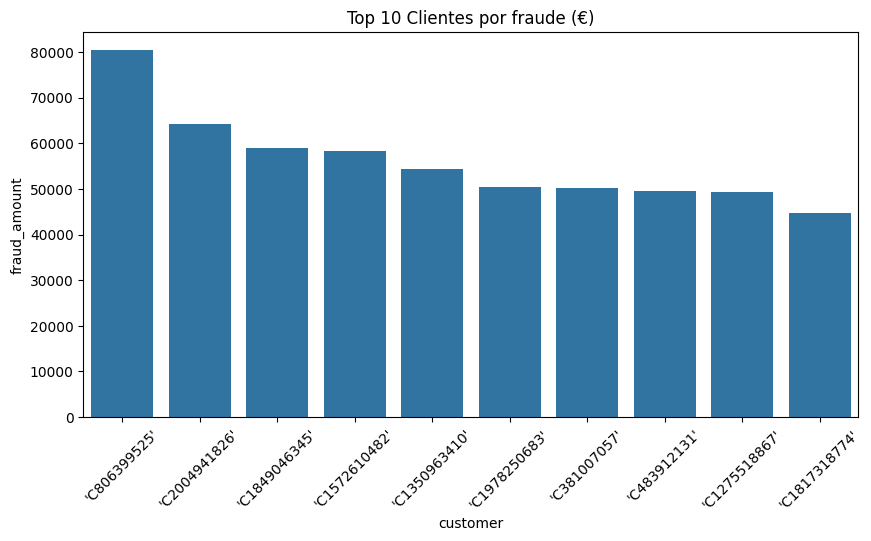

In [33]:
top_customers = customer_analysis.sort_values('fraud_amount', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.index, y=top_customers['fraud_amount'])
plt.xticks(rotation=45)
plt.title('Top 10 Clientes por fraude (€)')
plt.show()

### Deteccion de clientes con comportamiento notable

In [35]:
suspicious_customers = customer_analysis[
    (customer_analysis['n_transactions'] < 10) &
    (customer_analysis['fraud_ratio'] > 0.5)
]

suspicious_customers.head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C1233811793',7,5,0.714286,1339.31,191.3300,1054.56
'C1809646275',5,4,0.800000,1351.55,270.3100,1286.79
'C650117238',8,5,0.625000,2917.90,364.7375,2807.99
